<a href="https://colab.research.google.com/github/chadiboudaher/mnist-digit-classifier-scikit-learn/blob/main/mnist_digit_classifier_sklearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/chadiboudaher/mnist-digit-classifier-scikit-learn.git

Cloning into 'mnist-digit-classifier-scikit-learn'...
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 15 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (15/15), 5.12 KiB | 1.71 MiB/s, done.
Resolving deltas: 100% (3/3), done.


# MNIST

MNIST is a set of 70000 small images of digits handwritten.

## Fetch the MNIST dataset from `OpenMl.org`

`as_frame` is set to False to get the data as NumPy array.

In [2]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml("mnist_784", as_frame=False)

In [3]:
X, y = mnist.data, mnist.target
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

## Images deescription

- 70,000 images.
- 784 features (28 x 28 pixels)
- each features is represented with an intensity from 0 to 255.

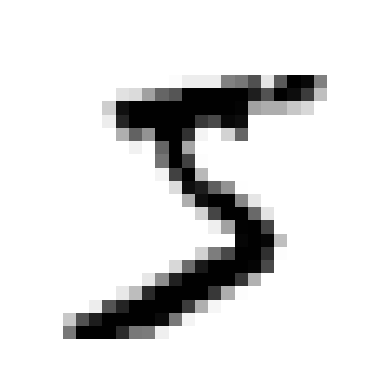

In [4]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
  image = image_data.reshape(28, 28)
  plt.imshow(image, cmap="binary")
  plt.axis("off")

some_digit = X[0]
plot_digit(some_digit)

## Create a train and test set

the dataset is already split into training and testing set, so we won't needing a `train_test_split` function.

In [8]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

## 1. Training a Binary Classifier

By training a nimary classifier we mean that we are trying to identify one digit. let's say 5 for example.

In [9]:
y_train_5 = (y_train == "5") # True for all 5's
y_test_5 = (y_test == "5")

## 2. Train and predict data

In [10]:
from sklearn .linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

SGDClassifier(random_state=42)

In [12]:
sgd_clf.predict([some_digit]), sgd_clf.predict([X[10]])

(array([ True]), array([False]))

## 3. Evaluate performance Measures

Evaluating a classifier is often significantly trickier than evaluating a regressor. There are many performence measures available.

* Measuring Accuracy Using **Cross-Validation**:
It is used to check how well it perform on unseen data while preventing overfitting. *K-Fold Cross Validation* is most common. It split the dataset into k equal-sized folds.

* **DummyClassifier**: it is a classifier that classifies data with basic rules without producing any insight from the training data.

***Accuracy***  is not the preferred performance measure for classifiers, especially when dealing with skewed datasets. A much better way is to use the ***Confusion Matrix***.

In [13]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf,
                X_train,
                y_train_5,
                cv = 3,
                scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

In [14]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train_5)
cross_val_score(dummy_clf,
                X_train,
                y_train_5,
                cv = 3,
                scoring="accuracy")
print(any(dummy_clf.predict(X_train)))

False


In [15]:
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.90965, 0.90965, 0.90965])

## 3.1 Confusion Matrix

In [17]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)
y_train_pred

array([ True, False, False, ...,  True, False, False])

In [18]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_train_5, y_train_pred)

array([[53892,   687],
       [ 1891,  3530]])

In [19]:
y_train_perfect_predictions = y_train_5

confusion_matrix(y_train_5, y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]])

## 3.2 Precision and recall

Our 5-detector does not look as good as we can see in the below results.

**Increasing** precision **reduces** recall, and vice versa. This is called `precision/recall trade-off`


In [20]:
from sklearn.metrics import precision_score, recall_score

precision_score(y_train_5,
                y_train_pred)

0.8370879772350012

In [21]:
recall_score(y_train_5,
             y_train_pred)

0.6511713705958311

In [22]:
from sklearn.metrics import f1_score

f1_score(y_train_5,
         y_train_pred)

0.7325171197343847

## The Precision/Recall Trade-of

In [23]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([2164.22030239])

In [24]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([ True])

In [25]:
threshold = 3000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

### Which Threshold

How do we know which threshold to use?
One option is to use the cross_val_predict() function to get the scores of all instances in the training set.

In [26]:
y_scores = cross_val_predict(sgd_clf,
                             X_train,
                             y_train_5,
                             cv=3,
                             method="decision_function")

In [27]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

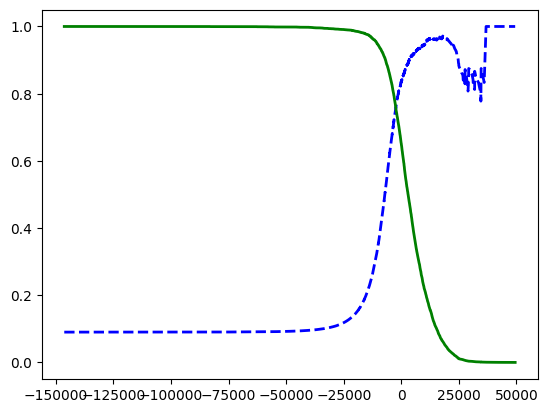

In [31]:
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.plot(threshold, 0, 1, "k", label="Threshold")
plt.show();

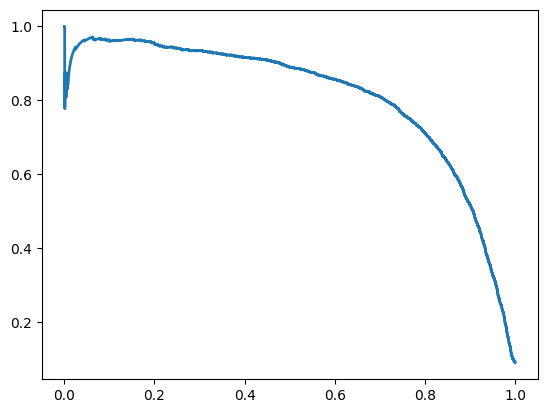

In [32]:
plt.plot(recalls, precisions, linewidth=2,
label="Precision/Recall curve")
plt.show()